In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
import torch.optim as optim

import splitfolders
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader

import lightning as pl


In [2]:
raw_train_data = datasets.ImageFolder(root = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSetTrainValidTest1.1/train", transform = None)

In [3]:
#Normalize
def get_mean_and_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    
    for data, _ in loader:
        # data shape: [batch_size, channels, height, width]
        # Mean over batch, height, and width dimensions (dim 0, 2, 3)
        #Collapse the batch size, width, and height to get r,g,b meanss
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1
        
    mean = channels_sum / num_batches
    # std = sqrt(E[X^2] - (E[X])^2)
    std = (channels_squared_sum / num_batches - mean**2)**0.5
    
    return mean, std


In [3]:
transform_for_standardize = v2.Compose([
    v2.ToImage(),
    v2.Resize((224,224), antialias = True),
    v2.ToDtype(torch.float32, scale = True)
])
raw_train_data_setup = datasets.ImageFolder(root = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSetTrainValidTest1.1", transform = transform_for_standardize)

mean, std = get_mean_and_std(raw_train_data_setup)

dataset_mean = mean
dataset_std = std
print(f"mean: {dataset_mean}")
print(f"std: {dataset_std}")

NameError: name 'get_mean_and_std' is not defined

In [4]:

#Put later: 

#Mean: tensor([0.6035, 0.5844, 0.5521])
#Std: tensor([0.3443, 0.3326, 0.3460])

#1.   ToImage first into integers rather than image object 
#1.5  antialias, smooths out lost pixels in diagonals
#2    Do Resizing and Rotations easier on integers plus uses GPU instead
#3    Turn into floats as doing augmentation on floats are much harder 
#3.5  scale turns the image pixels from [0,255] -> [0,1]
#4.   Should Normalize later

#Other options:
# v2.RandomHorizontalFlip(p=0.5)
# v2.RandomAffine(degrees=0, translate=(0.1, 0.1))
# v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
# v2.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0))

train_transform = v2.Compose([
  #Already called ToImage nd ToDType
  v2.ToImage(),
  # v2.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), antialias=True),
  v2.Resize((224,224), antialias = True),
  v2.RandomRotation(20),
  v2.RandomHorizontalFlip(0.5),
  # v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
  v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
  v2.ToDtype(torch.float32, scale = True),
  v2.Normalize(mean = [0.6038, 0.5848, 0.5524], std = [0.3445, 0.3326, 0.3461])
])

test_transform = v2.Compose([
  v2.ToImage(),
  v2.Resize((224,224), antialias=True),
    
    # 3. Cut a perfect square from the middle
  # v2.CenterCrop(224),
  v2.ToDtype(torch.float32, scale = True),
  v2.Normalize(mean = [0.6038, 0.5848, 0.5524], std = [0.3445, 0.3326, 0.3461])
])

train_data = datasets.ImageFolder(root = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSetTrainValidTest1.1/train", transform= train_transform)

val_data = datasets.ImageFolder(root = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSetTrainValidTest1.1/val", transform = test_transform)

test_data = datasets.ImageFolder(root = "/home/dghtan/Projects/Pokemon-Image-Prediction/CleanedDataCopy/MasterDataSetTrainValidTest1.1/test", transform = test_transform)


batch_size = 16
#pin_memory = True (Use with stronger gpus)
train_loader = DataLoader(
  dataset = train_data,
  batch_size= batch_size,
  shuffle = True,
  num_workers= 2,
  drop_last= False
)

val_loader = DataLoader(
  dataset = val_data,
  batch_size= batch_size,
  shuffle= False,
  num_workers= 2,
  drop_last= False
)

test_loader = DataLoader(
  dataset = test_data,
  batch_size= batch_size,
  shuffle= False,
  num_workers= 2,
  drop_last= False
)



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7581443..1.2934033].


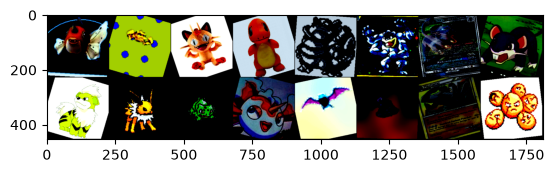

TRUE LABEL:  Seaking Geodude Meowth Charmander Blastoise Machamp Persian Rattata Growlithe Jolteon Bulbasaur Goldeen Golbat Grimer Machamp Exeggcute


In [38]:
def imshow(img):
    # img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
# print(images[4].size())
# show images
def showImBatch(image, label):
    imshow(torchvision.utils.make_grid(image))
    # print labels
    print('TRUE LABEL: ', ' '.join(f'{train_data.classes[label[j]]:5s}' for j in range(batch_size)))
showImBatch(images, labels)


2. Building CNN

In [39]:
#224 x 224
#Aim to 256 - 4096 features
class Net(nn.Module):
  #, conv, pool, fc
  def __init__(self):
    super().__init__()

    # (# channels, #filters/output channels, square filter size)
    self.conv1 = nn.Conv2d(3,6,5)
    #Takes the max value of the 2x2 in the filters in conv
    self.pool = nn.MaxPool2d(2,2)

    self.conv2 = nn.Conv2d(6,12,5)

    self.conv3 = nn.Conv2d(12, 18, 3)

    self.pool3 = nn.MaxPool2d(3,3)

    
    # self.fc1 = nn.Linear(12 * 85 * 85, 900)
    self.fc1 = nn.Linear(18*17*17, 900)
    self.fc2 = nn.Linear(900, 300)
    self.fc3 = nn.Linear(300, 151)


  def forward(self, x):
    x = F.relu(self.conv1(x))
    x = self.pool(x)

    x = F.relu(self.conv2(x))
    x = self.pool(x)

    x = F.relu(self.conv3(x))
    x = self.pool3(x)
    x = torch.flatten(x,1)

    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x
net = Net()

3. Definning the Loss Function

In [ ]:
criterion = nn.CrossEntropyLoss()

#-ln( e^(output of right class ) / sum(e^(output of other classes)))
#Sum this for all images in the batch

optimizer = optim.SGD(net.parameters(), lr = 0.002, momentum= 0.9)
# optimizer = optim.AdamW(
#     net.parameters(),              
#     lr=1e-3,           # Learning rate (3e-4 if fails to converge)
#     weight_decay=1e-2  # L2 regularization penalty) (1e-4 if underfitting)
# )

4. Trainning The CNN

In [41]:
import copy
import warnings

# Suppress UserWarnings specifically from the PIL.Image module
warnings.filterwarnings("ignore", category=UserWarning, module="PIL.Image")

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_weights = None

    def __call__(self, val_loss, model):
        # If loss improves by more than min_delta
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            # Save the best weights
            self.best_model_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_weights(self, model):
        if self.best_model_weights is not None:
            model.load_state_dict(self.best_model_weights)
        return model

In [42]:
early_stopper = EarlyStopping(patience=2, min_delta=0)

for epoch in range(30):
  net.train()
  running_loss = 0.0

  #Loop through the batches in train loader
  for i, data in enumerate(train_loader,0):
    #Get the image details and the label its classified under for the BATCH?
    inputs, labels = data

    #Reset the gradients from stacking onto eachother
    optimizer.zero_grad()

    #Forward, backward, optimizing step
    outputs = net(inputs)
    loss = criterion(outputs, labels )
    loss.backward()
    optimizer.step()

    # print statistics
    running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)

    if i % 2000 == 1999:    # print every 2000 mini-batches
        print(f'[{epoch}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
        running_loss = 0.0
  
  #new stuff

  net.eval()   # Turns off Dropout
  val_loss = 0.0
  
  # Turn off gradient tracking (CRITICAL for validation)
  with torch.no_grad():
      for val_x, val_y in val_loader:
          val_predictions = net(val_x)
          batch_loss = criterion(val_predictions, val_y)
          val_loss += batch_loss.item()

# Calculate the average validation loss for this epoch
  avg_val_loss = val_loss / len(val_loader)
  
  print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
  
  # ==========================
  # 3. EARLY STOPPING CHECK
  # ==========================
  # Pass the calculated validation loss to your custom class
  early_stopper(avg_val_loss, net)
  
  if early_stopper.early_stop:
      print(f"Early stopping triggered! Halted at epoch {epoch}")
      break

# After the loop finishes, load the best saved weights
net = early_stopper.load_best_weights(net)
    
print('Finished Training')

[0,  2000] loss: 4.619
Epoch 0 | Train Loss: 1.2481 | Val Loss: 3.9173
[1,  2000] loss: 3.683
Epoch 1 | Train Loss: 1.0437 | Val Loss: 3.2281
[2,  2000] loss: 3.178
Epoch 2 | Train Loss: 0.9385 | Val Loss: 2.9674
[3,  2000] loss: 2.901
Epoch 3 | Train Loss: 0.8650 | Val Loss: 2.8156
[4,  2000] loss: 2.710
Epoch 4 | Train Loss: 0.8067 | Val Loss: 2.6906
[5,  2000] loss: 2.558
Epoch 5 | Train Loss: 0.7879 | Val Loss: 2.6106
[6,  2000] loss: 2.435
Epoch 6 | Train Loss: 0.7513 | Val Loss: 2.5685
[7,  2000] loss: 2.340
Epoch 7 | Train Loss: 0.7262 | Val Loss: 2.6009
[8,  2000] loss: 2.244
Epoch 8 | Train Loss: 0.6954 | Val Loss: 2.5214
[9,  2000] loss: 2.190
Epoch 9 | Train Loss: 0.6696 | Val Loss: 2.4065
[10,  2000] loss: 2.122
Epoch 10 | Train Loss: 0.6571 | Val Loss: 2.4334
[11,  2000] loss: 2.067
Epoch 11 | Train Loss: 0.6368 | Val Loss: 2.4757
Early stopping triggered! Halted at epoch 11
Finished Training


4. Validation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7581443..1.2934033].


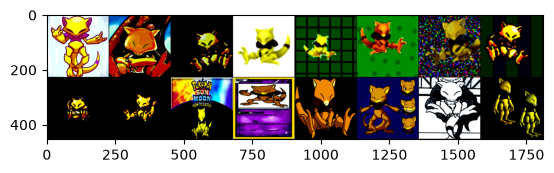

TRUE LABEL:  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Abra 
Predicted:   Weedle Meowth Abra  Abra  Staryu Staryu Farfetchd Abra  Shellder Abra  Exeggutor Hypno Abra  Alakazam Geodude Kakuna


In [43]:
val_dataiter = iter(val_loader)
# test_dataiter = iter(test_loader)
images, labels = next(val_dataiter)

showImBatch(images, labels)

outputs = net(images)

#torch max returns value/score then prediction index which we want
_, predicted = torch.max(outputs, 1)

print('Predicted:  ' ,' '.join(f'{test_data.classes[predicted[j]]:5s}' for j in range(batch_size)))

#print(' '.join(f'{train_data.classes[label[j]]:5s}' for j in range(batch_size)))

In [44]:
def getValAcc(loadScore = False):
    net.eval()
    # prepare to count predictions for each class
    correct_pred = {classname: 0 for classname in val_data.classes}
    total_pred = {classname: 0 for classname in val_data.classes}

    # again no gradients needed
    with torch.no_grad():
        for data in val_loader:
            images, labels = data
            outputs = net(images)
            _, predictions = torch.max(outputs, 1)
            # collect the correct predictions for each class
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[test_data.classes[label]] += 1
                total_pred[test_data.classes[label]] += 1
    # Get accuracy
    total_accuracy = 0
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        total_accuracy += float(correct_count) / total_pred[classname]
        if loadScore:
            print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')
    return (total_accuracy*100)/151
accuracy = getValAcc(loadScore= True)
print(accuracy)

Accuracy for class: Abra  is 51.6 %
Accuracy for class: Aerodactyl is 35.0 %
Accuracy for class: Alakazam is 38.5 %
Accuracy for class: Arbok is 64.1 %
Accuracy for class: Arcanine is 55.6 %
Accuracy for class: Articuno is 54.3 %
Accuracy for class: Beedrill is 46.7 %
Accuracy for class: Bellsprout is 36.8 %
Accuracy for class: Blastoise is 43.2 %
Accuracy for class: Bulbasaur is 69.2 %
Accuracy for class: Butterfree is 82.5 %
Accuracy for class: Caterpie is 63.2 %
Accuracy for class: Chansey is 57.5 %
Accuracy for class: Charizard is 48.7 %
Accuracy for class: Charmander is 69.4 %
Accuracy for class: Charmeleon is 52.6 %
Accuracy for class: Clefable is 63.2 %
Accuracy for class: Clefairy is 48.6 %
Accuracy for class: Cloyster is 42.9 %
Accuracy for class: Cubone is 48.7 %
Accuracy for class: Dewgong is 25.7 %
Accuracy for class: Diglett is 35.1 %
Accuracy for class: Ditto is 53.1 %
Accuracy for class: Dodrio is 45.9 %
Accuracy for class: Doduo is 51.4 %
Accuracy for class: Dragonair i

5. Saving

In [35]:
PATH = '/home/dghtan/Projects/Pokemon-Image-Prediction/SavedModels/model16_weights.pt'
torch.save(net.state_dict(), PATH)